# Dynamical simulation of Climate Data

We will use the implementations within the `climate_data_hackathon` package to load CO2 emissions data, create objects to be mapped to a carbon footprint, and dynamically congregate them onto the shape of a foot.

In [1]:
!uv add cmcrameri

Resolved 35 packages in 6ms
Audited 34 packages in 96ms


In [2]:
from climate_data_hackathon import dynamic_simulation as ds

In [3]:
from pathlib import Path
from dataclasses import dataclass, field as dcfield
import os
import numpy as np

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
import cmcrameri.cm as cm

## Load data

In [5]:
FPATH_co2_data = Path("..") / "data" / "co2-emissions" / "co2-emissions-emissions-mmtco2.csv"

In [6]:
from dataclasses import dataclass

def safe_float(possibly_float: str, default_value = None) -> float | None:
    try:
        return float(possibly_float)
    except:
        return default_value

@dataclass
class CountryAndData:
    name: str
    code: str
    data: list[float]

    @classmethod
    def from_line(cls, line: str):
        name, code, data = line.strip().split(",",2)
        data = [safe_float(v) for v in data.split(",")]
        return cls(name=name, code=code, data=data)

In [7]:
countries = dict()
with open(FPATH_co2_data, "r") as f:
    print(first_line:=f.readline())
    years = [
        int(v) 
        for v in first_line.strip().split(",",2)[-1].split(",")
    ]
    
    for line in f.readlines():
        cad = CountryAndData.from_line(line)
        countries[cad.name] = cad
len(countries)
print(years)

Country,Code,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023

[1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [8]:
d = [[ safe_float(v,np.nan) for v in cad.data ] for cad in countries.values()]
MEDIAN_co2 = np.nanmedian(d)
np.nanmean(d), np.nanmedian(d)

(np.float64(726.5104168405752), np.float64(9.905162872))

## Selecting the final year

In [58]:
VERLET_DAMPING = 0.985
dt = 0.001

In [10]:
year_index = -1

In [11]:
for country, cad in countries.items():
    if cad.data[year_index] is not None:
        print(f"{cad.name:^35} | {cad.code:>4}")

               Aruba                |  ABW
            Afghanistan             |  AFG
              Africa                | AFRC
              Angola                |  AGO
              Albania               |  ALB
       United Arab Emirates         |  ARE
             Argentina              |  ARG
              Armenia               |  ARM
          American Samoa            |  ASM
          Asia & Oceania            | ASOC
            Antarctica              |  ATA
        Antigua and Barbuda         |  ATG
             Australia              |  AUS
              Austria               |  AUT
            Azerbaijan              |  AZE
              Burundi               |  BDI
              Belgium               |  BEL
               Benin                |  BEN
           Burkina Faso             |  BFA
            Bangladesh              |  BGD
             Bulgaria               |  BGR
              Bahrain               |  BHR
            The Bahamas             |  BHS
      Bosni

In [12]:
GROUP_CODES_exclude = (
    "ASOC", "CSAM", "EU27", "EURA", "EURO", "MIDE", "NOAM", "NOEC", "OEAO", "OECD", "OEEU", "OENA", "OPAF", "OPEC", "OPNO", "OPSA", 
    "WORL", "WP11", "WP12", "WP19", "WP21", "WP23", "WP24", "WP26", "WP22",
)

In [13]:
def co2_to_mass(co2: float) -> float:
    #co2 given in million metric tonnes
    return co2 / MEDIAN_co2 * 0.7

def co2_to_radius(co2: float) -> float:
    rmin = 1
    return rmin + 1 / np.pi * (np.log10(co2) - np.log10(MEDIAN_co2))

In [14]:
class Point(ds.Point):
    def to_patch(self) -> Circle:
        return Circle(
            xy=self.x,
            radius = self.radius,
            facecolor=self.color
        )

In [26]:
# create Point objects
points = {
    c: Point(
        initial_x = np.zeros((2,)),
        mass= co2_to_mass(cad.data[year_index]), 
        radius= co2_to_radius(cad.data[year_index]), 
        name = cad.name, 
        color=cm.batlowS(j),
        damping=VERLET_DAMPING
    )
    for j,(c, cad) in enumerate(countries.items())
    if cad.code not in GROUP_CODES_exclude
    if cad.data[year_index] not in (None, 0.)
}
total_n = len(points)

15.786683783632688


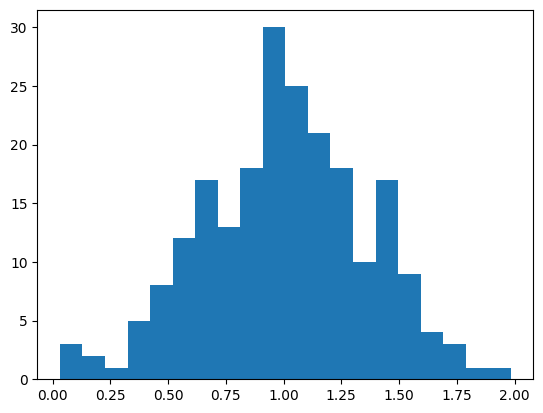

In [27]:
# determine distribution of radii
plt.hist((histd:=[p.radius for p in points.values()]), bins=20)
print((simulation_scale:=np.sqrt(np.sum(np.power(histd,2)))))
plt.show()

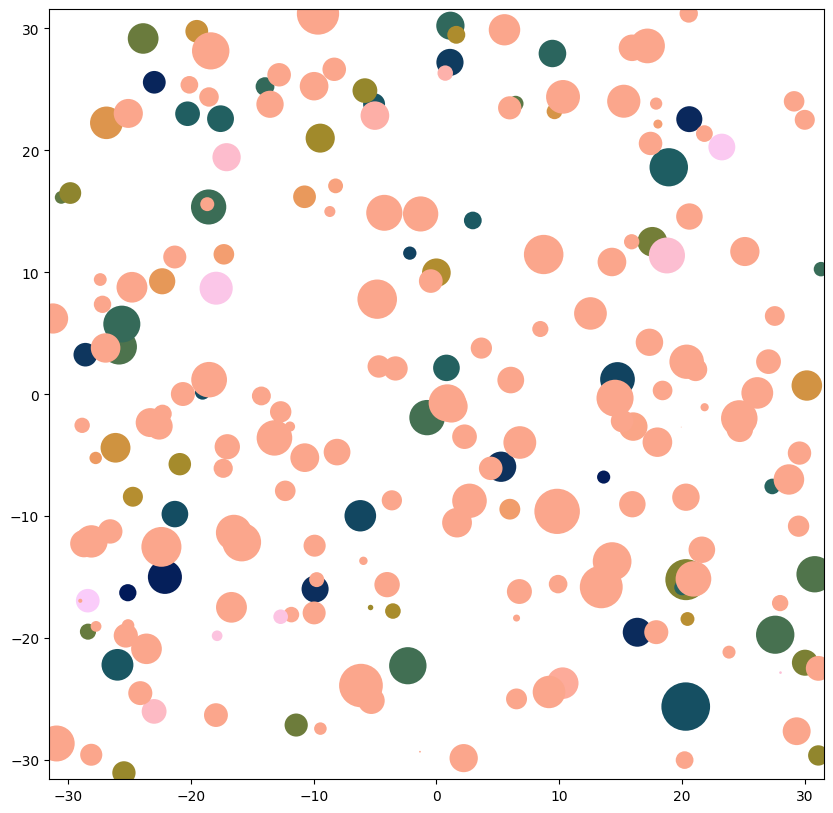

CPU times: user 283 ms, sys: 19.9 ms, total: 303 ms
Wall time: 287 ms


In [70]:
%%time
# distribute Point objects throughout the domain [-2*simulation_scale, 2*simulation_scale]^2
rng = np.random.default_rng()

space_bounds = [-2*simulation_scale, 2*simulation_scale]

for point in points.values():
    point.move_to(
        #new_x = np.clip(rng.multivariate_normal(mean=[0,0], cov=np.identity(2)*5*simulation_scale).squeeze(), *space_bounds)
        new_x = rng.uniform(*space_bounds, size=2)
    )

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.set_xlim(space_bounds)
ax.set_ylim(space_bounds)

circles_handles = {
    c: ax.add_patch(p.to_patch())
    for c, p in points.items()
}

plt.show()
plt.clf()
plt.close()

In [46]:
!uv add scikit-learn

Resolved 35 packages in 4ms
Audited 34 packages in 1ms


In [47]:
from sklearn.neighbors import NearestNeighbors

In [48]:
nn_model = NearestNeighbors(n_neighbors=5, radius=3)

In [49]:
%%time

position_data = np.array([
    p.x
    for p in points.values()
])
distances, indices = nn_model.fit(position_data).kneighbors(position_data, return_distance=True)
# remove self from nearest neighbours set for each one
distances = distances[:,1:]
indices = indices[:,1:]

CPU times: user 2.2 ms, sys: 1.52 ms, total: 3.73 ms
Wall time: 2.91 ms


In [50]:
nn_model = NearestNeighbors(n_neighbors=5, radius=3)
def get_nearest_neighbours(points):
    position_data = np.array([
        p.x
        for p in points.values()
    ])
    distances, indices = nn_model.fit(position_data).kneighbors(position_data, return_distance=True)
    # remove self from nearest neighbours set for each one
    distances = distances[:,1:]
    indices = indices[:,1:]
    return distances, indices

In [51]:
def apply_partial_exclusion(points, f: float):
    distances, indices = get_nearest_neighbours(points=points)
    for i, (country, point) in enumerate(points.items()):
        for distance, index in zip(distances[i], indices[i]):
            # remove double computation
            if index < i:
                continue
            if distance < point.radius + (other:=list(points.values())[index]).radius:
                applied_exclusion = True
                point.apply_exclusion_displacement(other, fraction_reduce_overlap=f)
                point.reset_velocity()
                other.reset_velocity()

def apply_partial_exclusions(points, n: int, t: float = 1):
    f = t / n
    for _ in range(n):
        apply_partial_exclusion(points, f=f)

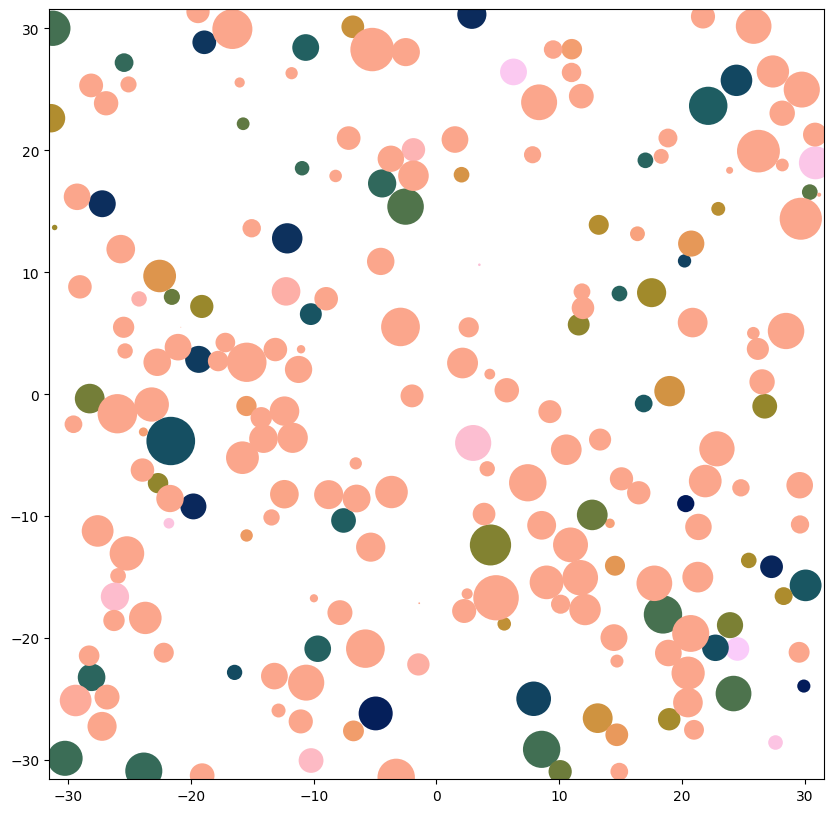

required 5 exclusion iterations
CPU times: user 292 ms, sys: 11 ms, total: 302 ms
Wall time: 300 ms


In [52]:
%%time
#applied_exclusion = True
#n_exclusions = 0
#while applied_exclusion:
#    applied_exclusion = False
#    n_exclusions += 1
#    distances, indices = get_nearest_neighbours(points=points)
#    for i, (country, point) in enumerate(points.items()):
#        for distance, index in zip(distances[i], indices[i]):
#            # remove double computation
#            if index < i:
#                continue
#            if distance < point.radius + (other:=list(points.values())[index]).radius:
#                applied_exclusion = True
#                point.apply_exclusion_displacement(other, fraction_reduce_overlap=1.5)
#                point.reset_velocity()
#                other.reset_velocity()

apply_partial_exclusions(points, n=5, t=2)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.set_xlim(space_bounds)
ax.set_ylim(space_bounds)

circles_handles = {
    c: ax.add_patch(p.to_patch())
    for c, p in points.items()
}

plt.show()
plt.clf()
plt.close()
print(f"required {n_exclusions} exclusion iterations")

In [62]:
def apply_forces(points, force_func):
    distances, indices = get_nearest_neighbours(points)
    for i, (country, point) in enumerate(points.items()):
        for distance, index in zip(distances[i], indices[i]):
            # remove double computation
            if index < i:
                continue
            other = list(points.values())[index]
            f_2_on_1 = force_func(point, other)
            point.add_force(f_2_on_1)
            other.add_force(-f_2_on_1)

In [63]:
def set_accelarations(points, dt: float, cap: float):
    [p.set_accelaration_from_forces().apply_partial_update(dt).cap_partial_dx(cap) for p in points.values()]

In [64]:
def simulate_step(points, force_func, dt, cap, f):
    # start the frame
    [p.start_frame() for p in points.values()]
    # determine k nearest neighbours and compute forces between them
    apply_forces(points, force_func)
    set_accelarations(points, dt, cap)
    apply_partial_exclusion(points, f=f)
    [p.update() for p in points.values()]
    return points

In [68]:
force_func = lambda p1, p2: ds.inverse_square_with_constant_at_proximity(p1,p2, G=5, r_cutoff=0.1, constant=-5)
simulate_step_curry = lambda ps: simulate_step(points=ps, force_func = force_func, dt = dt, cap=0.1, f=1.2)

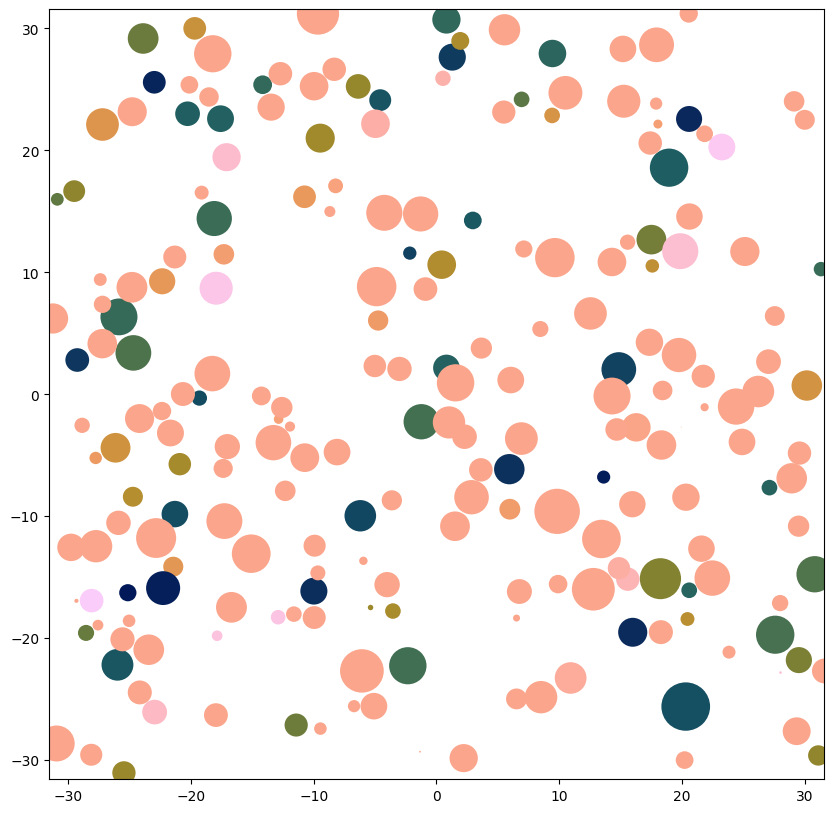

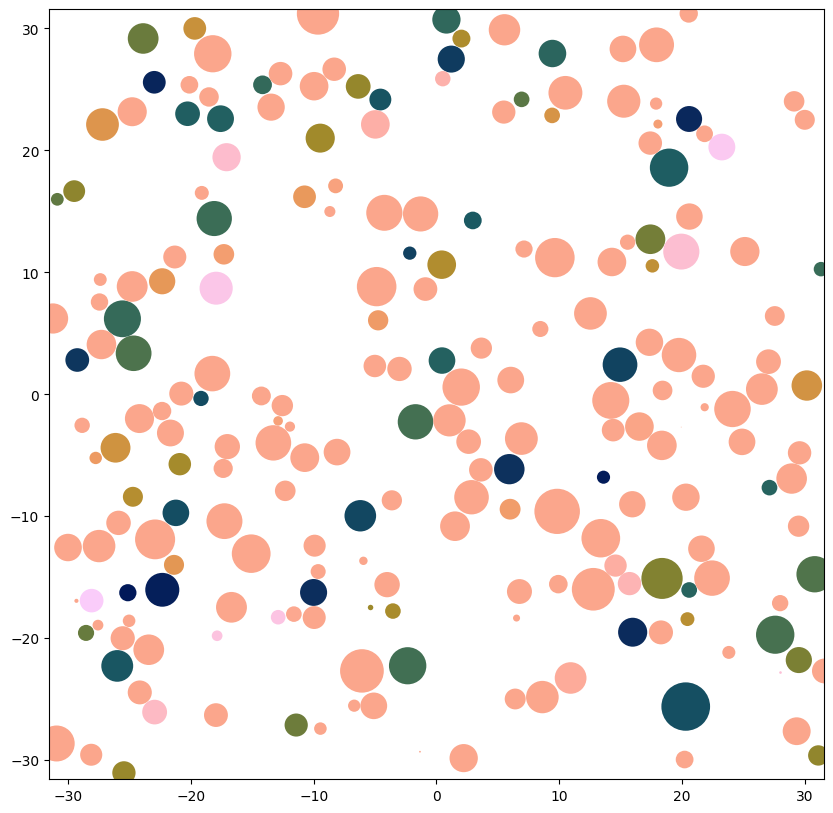

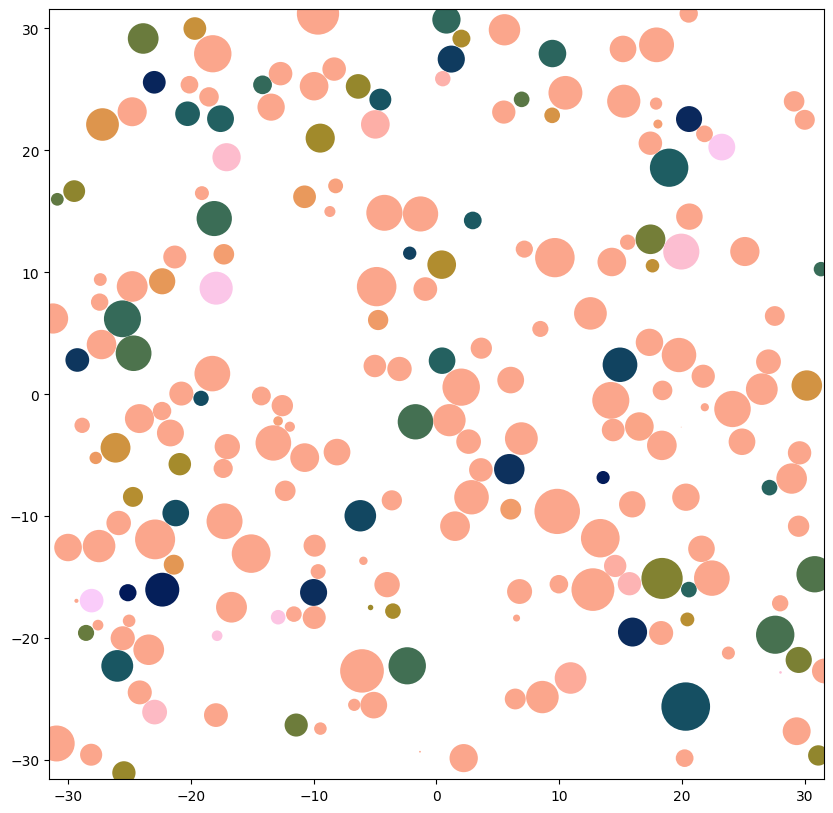

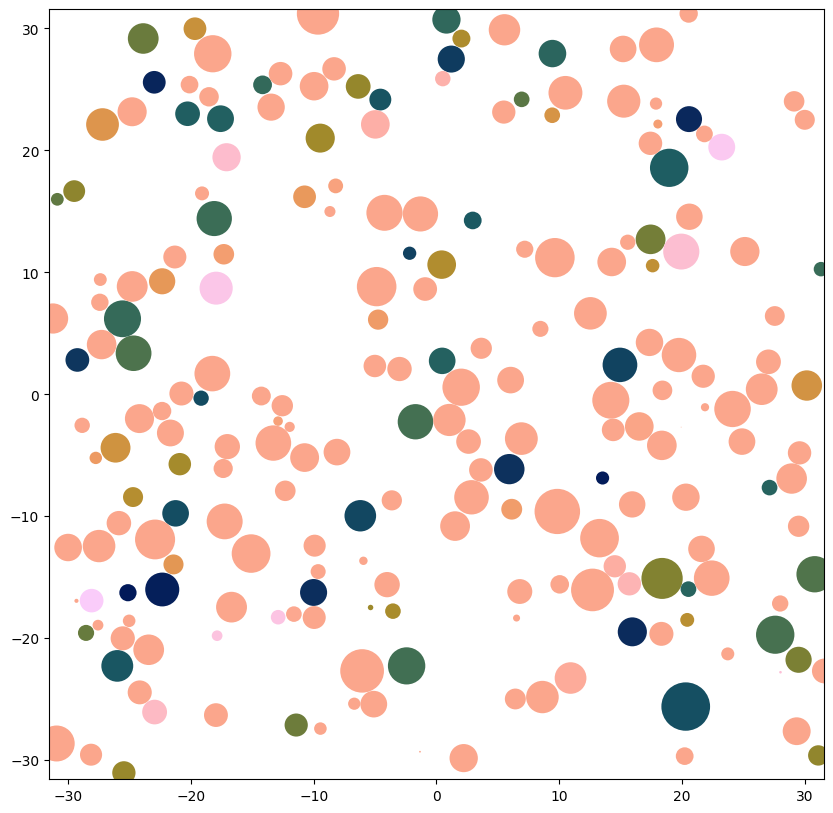

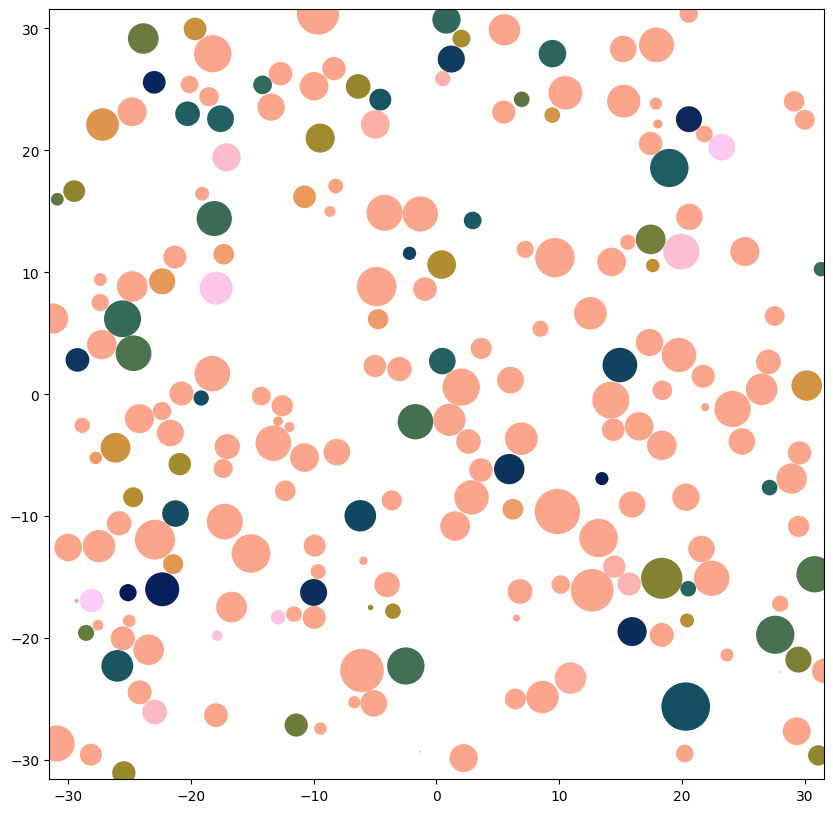

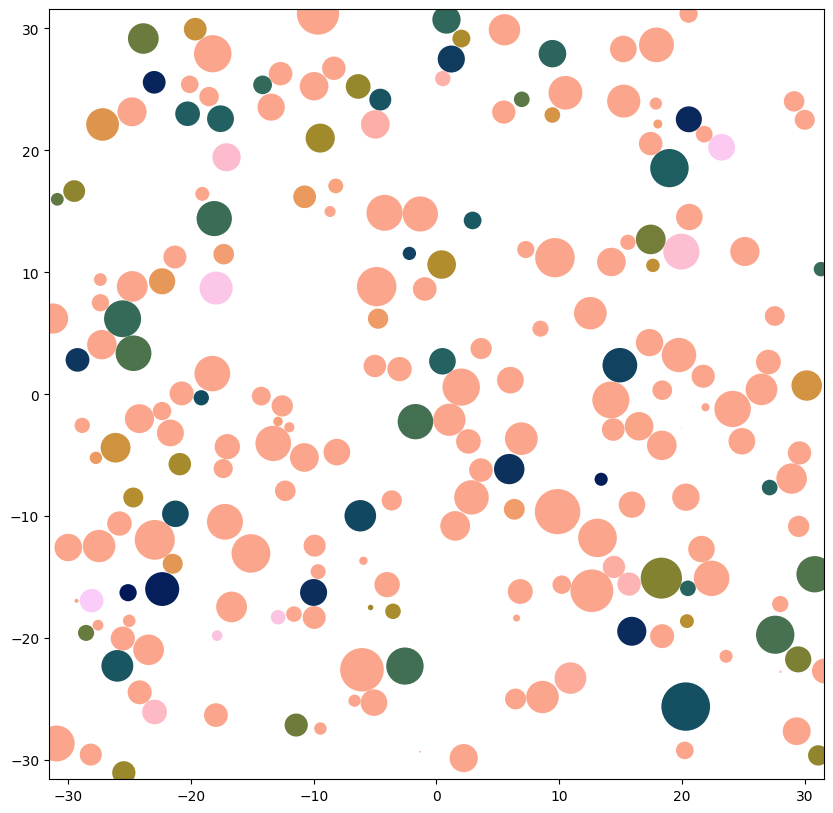

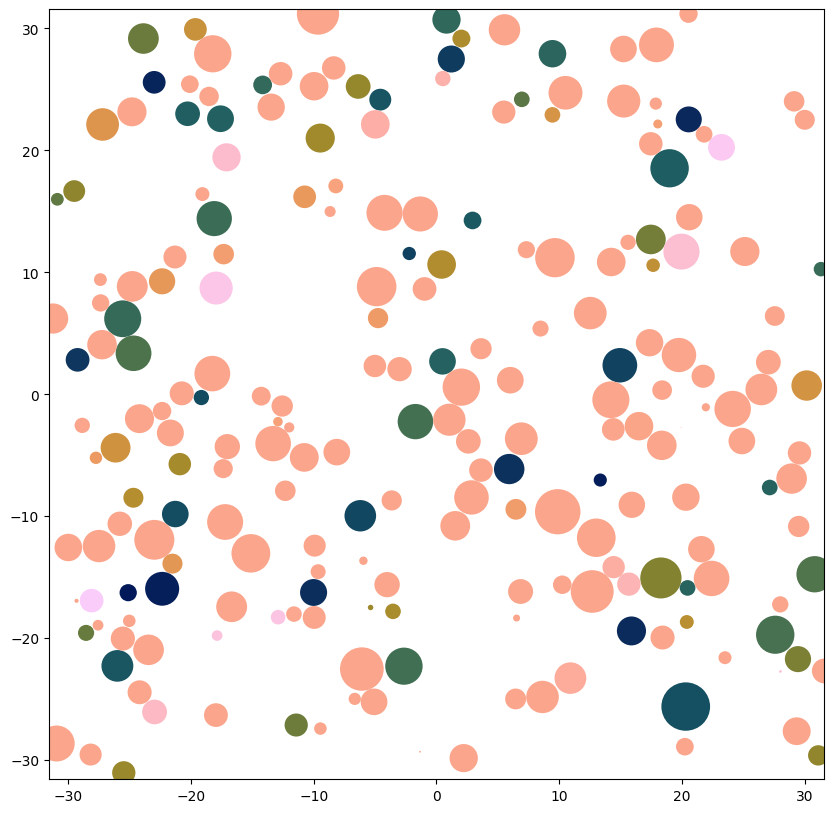

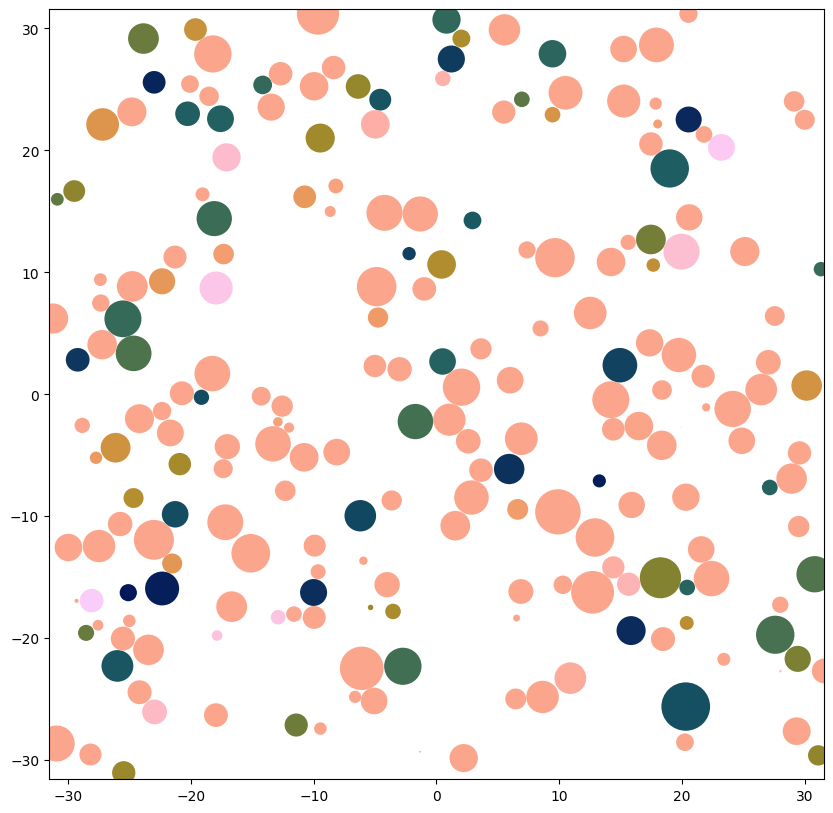

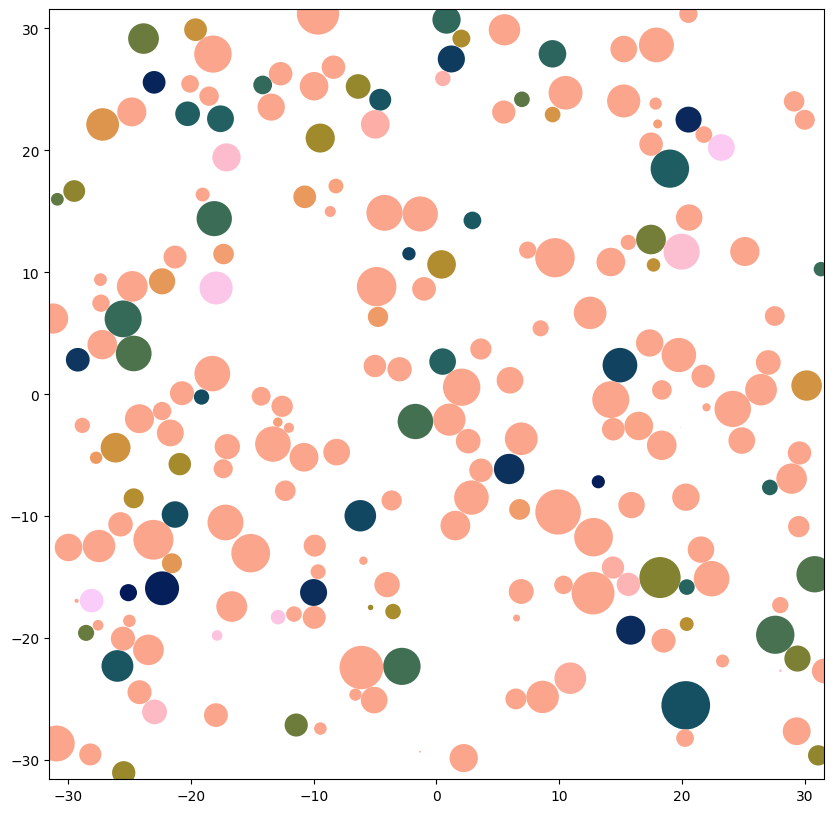

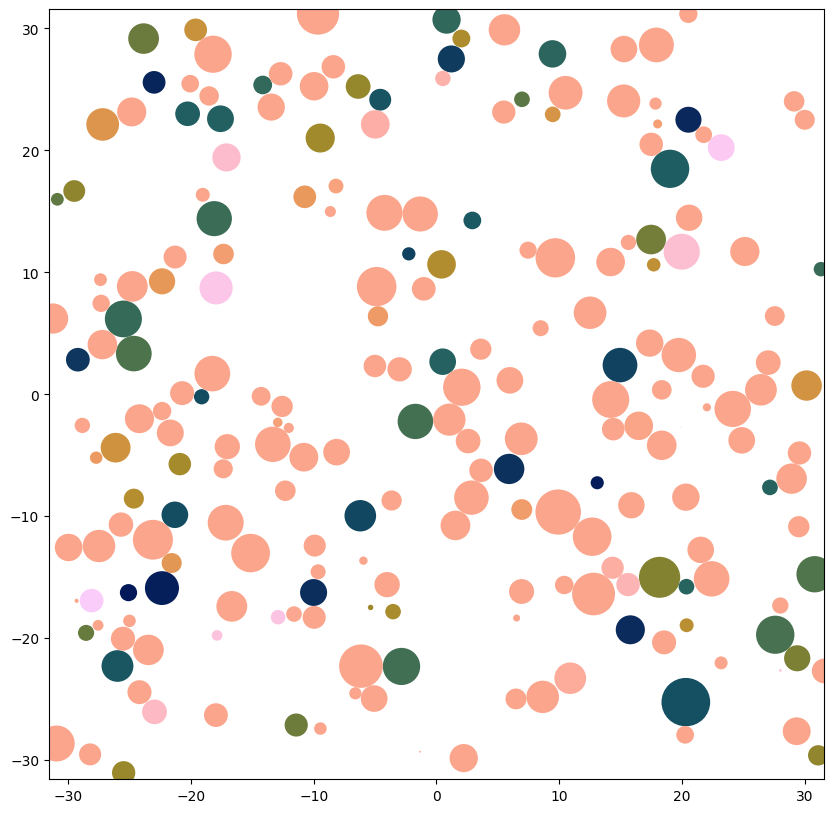

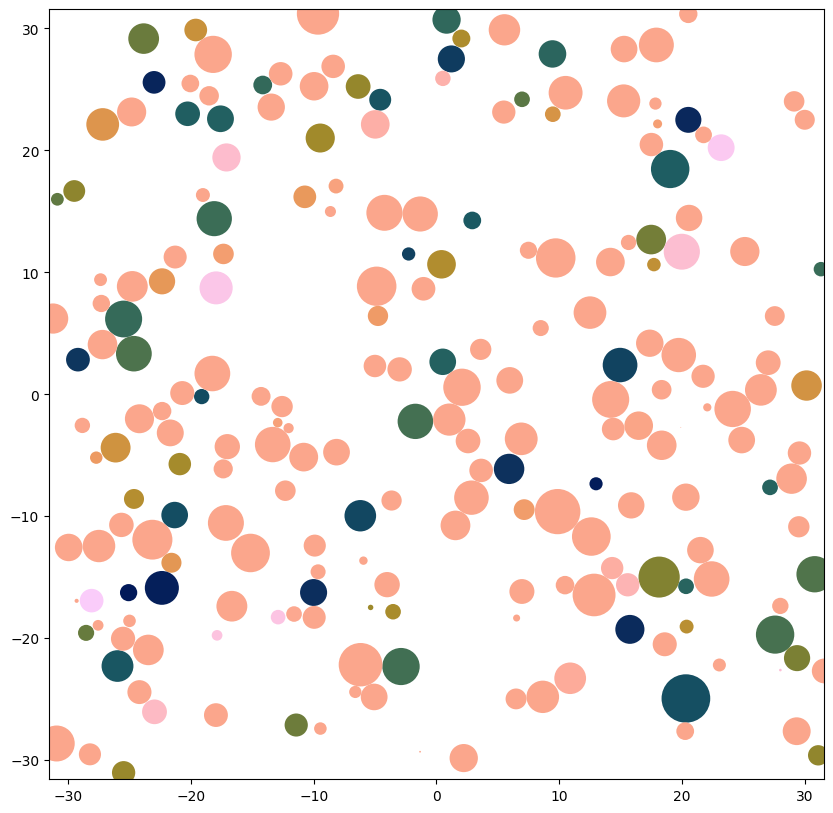

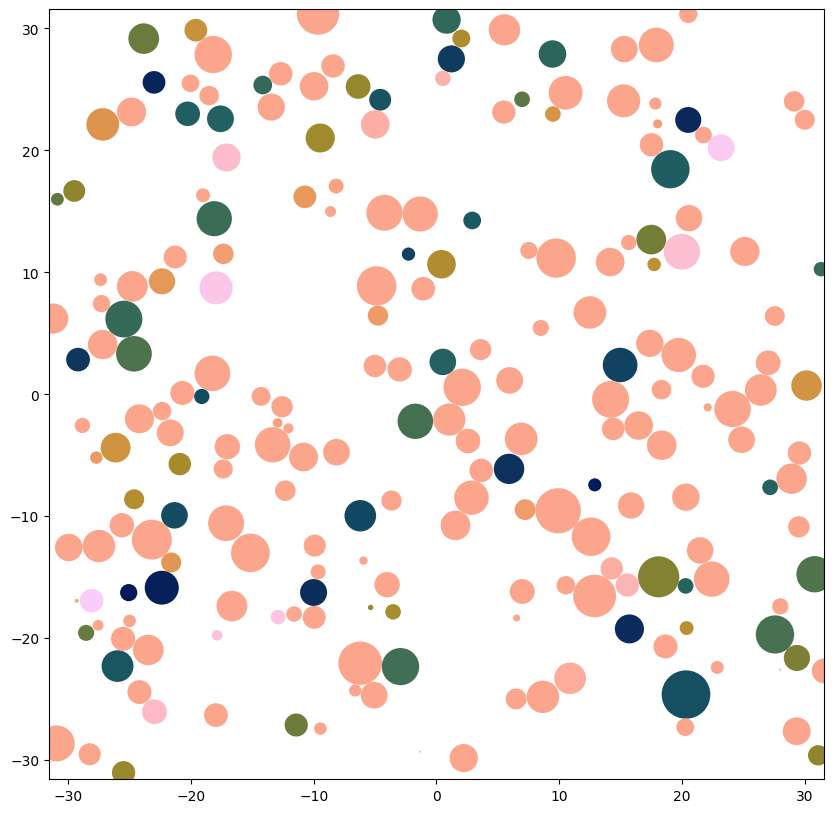

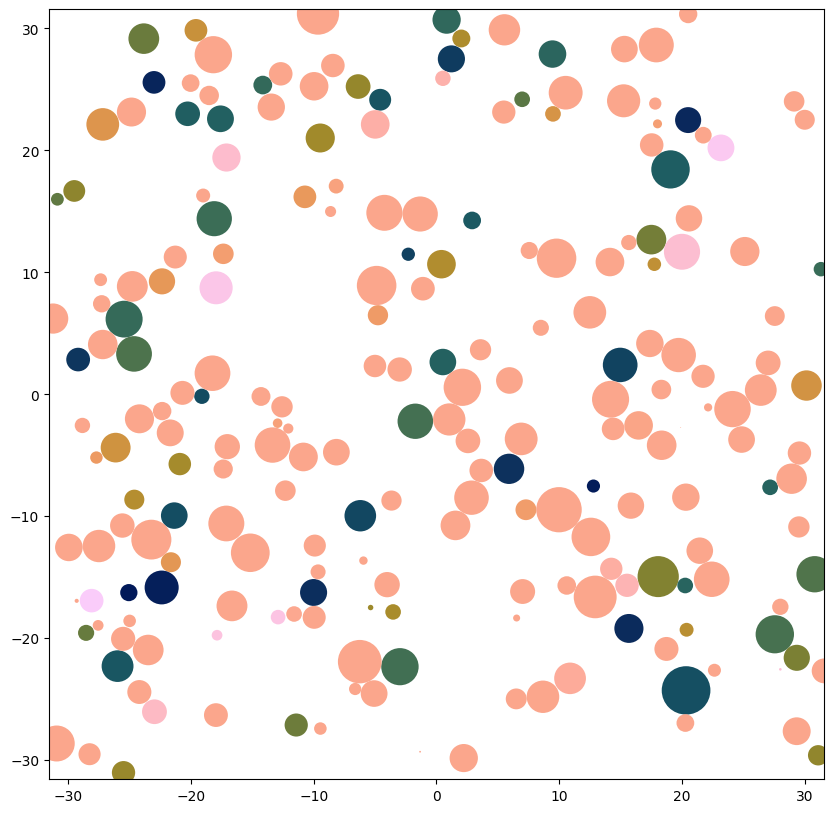

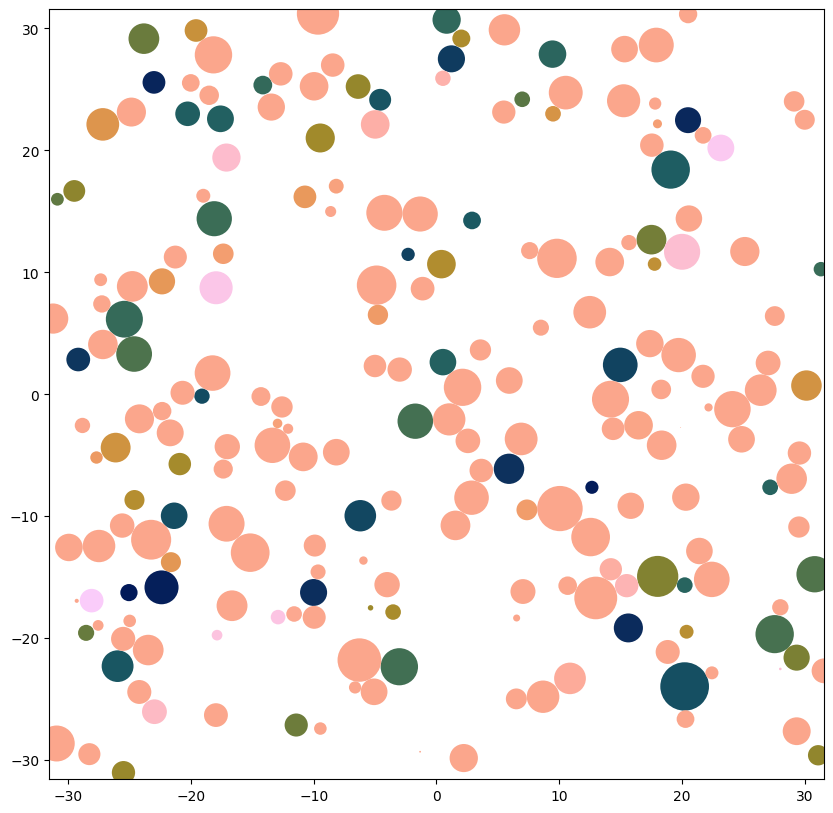

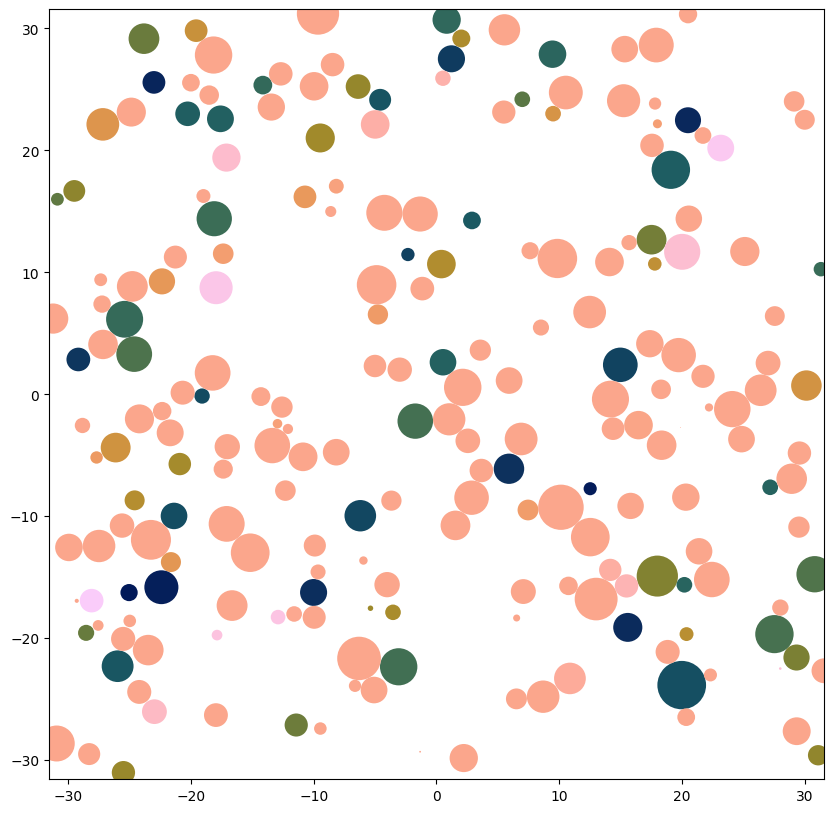

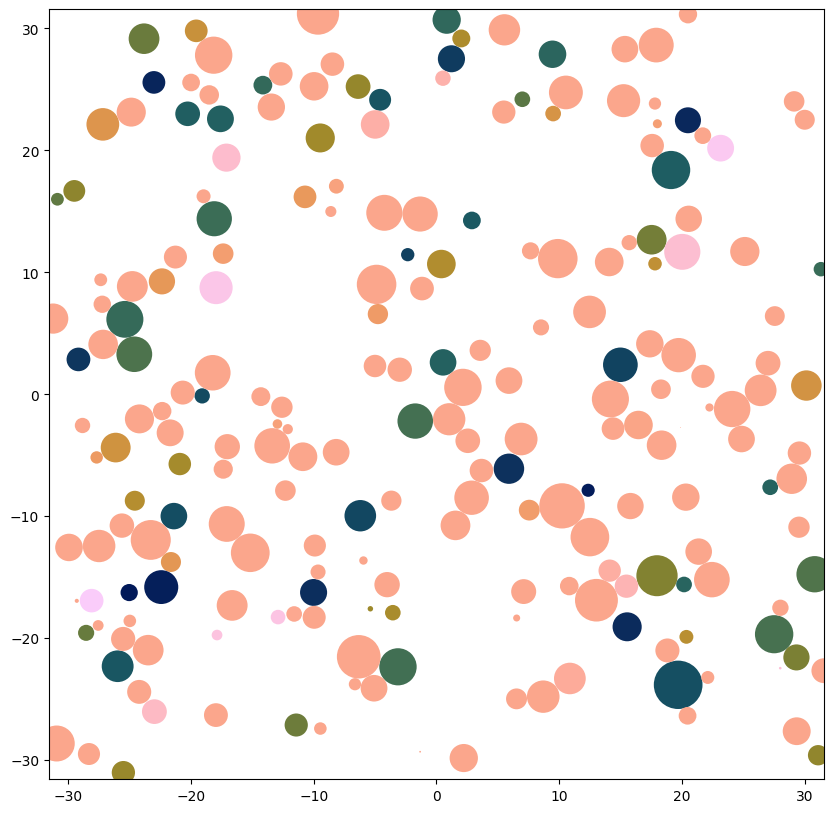

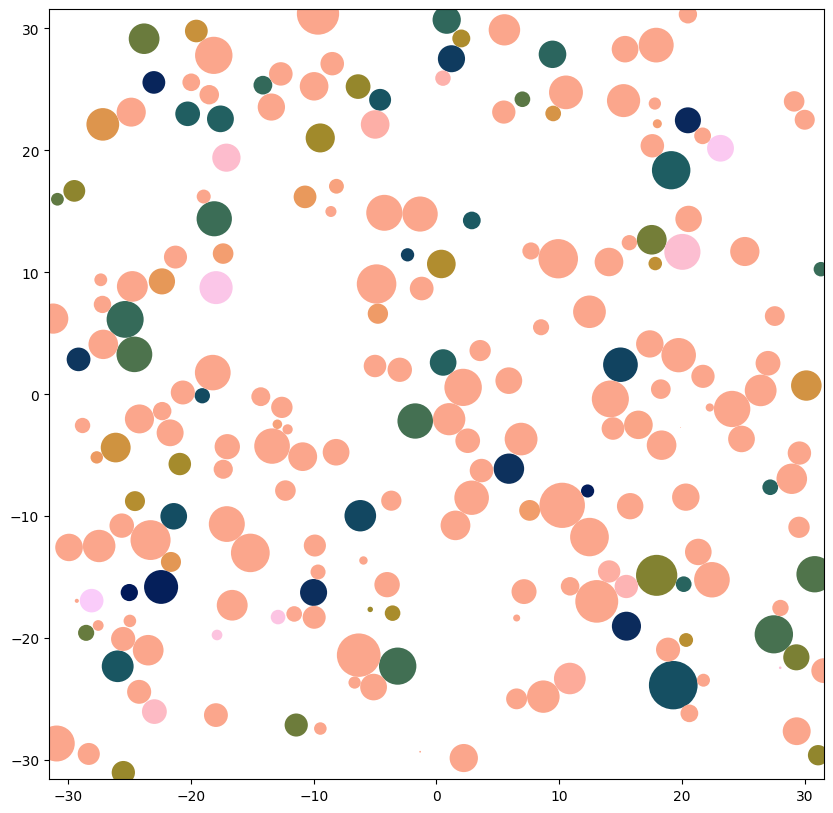

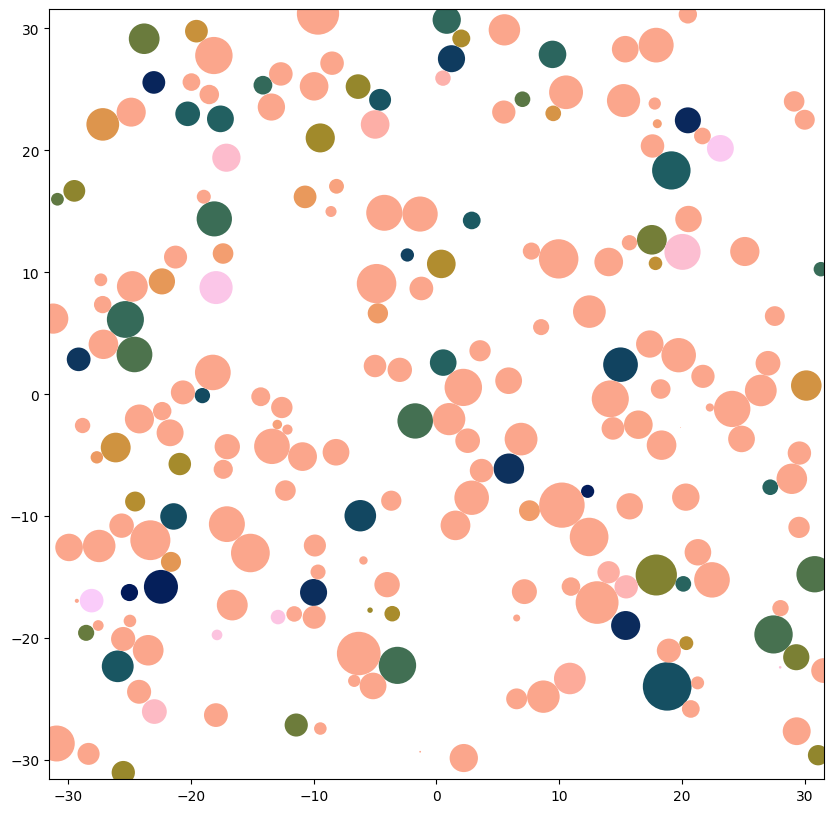

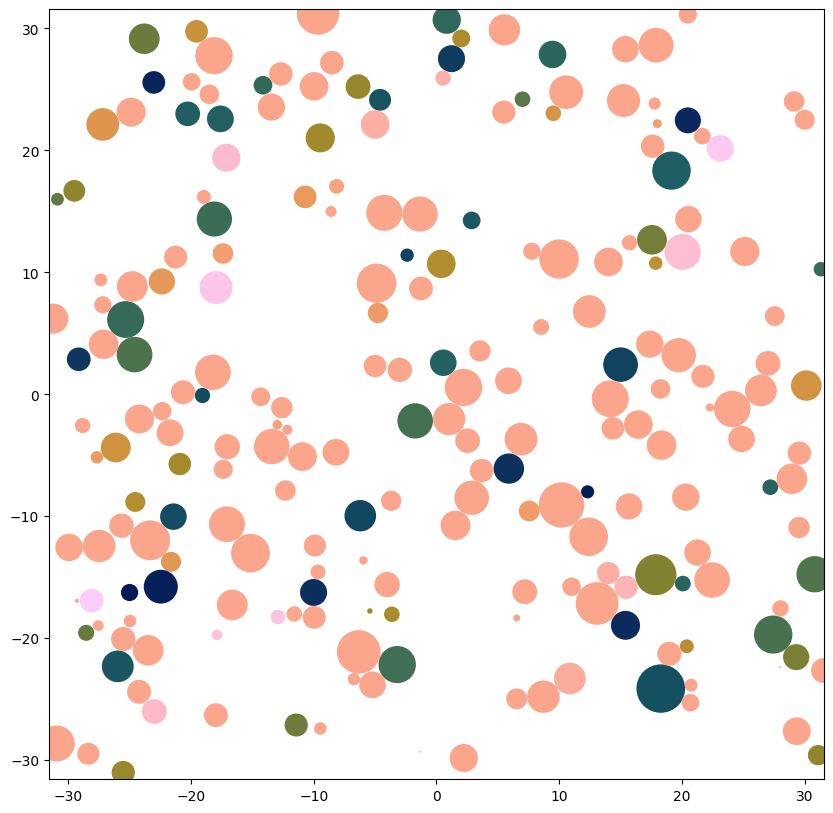

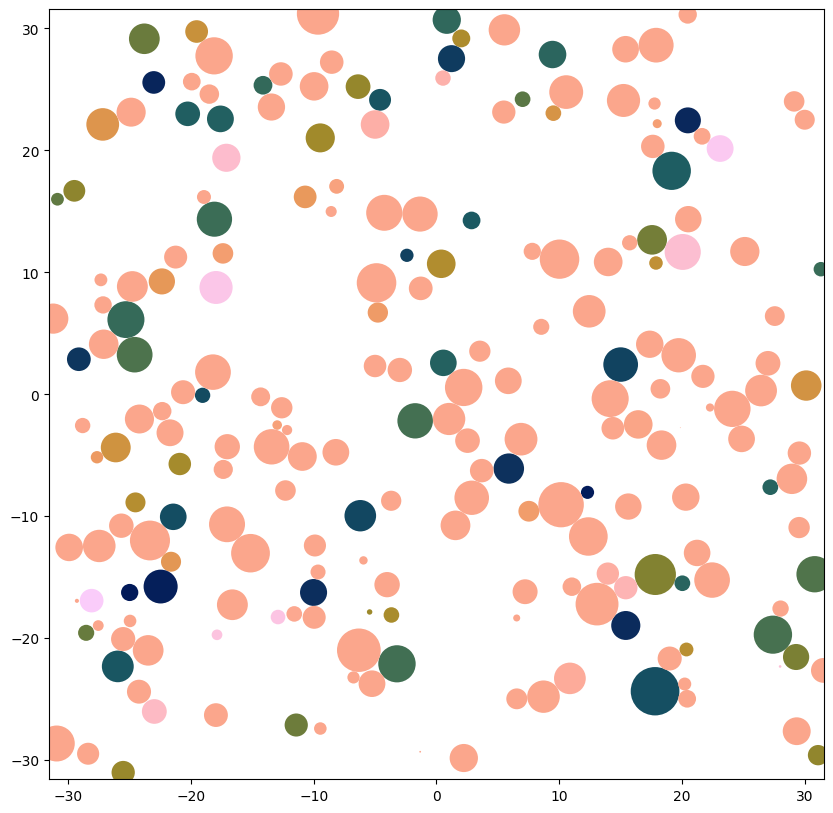

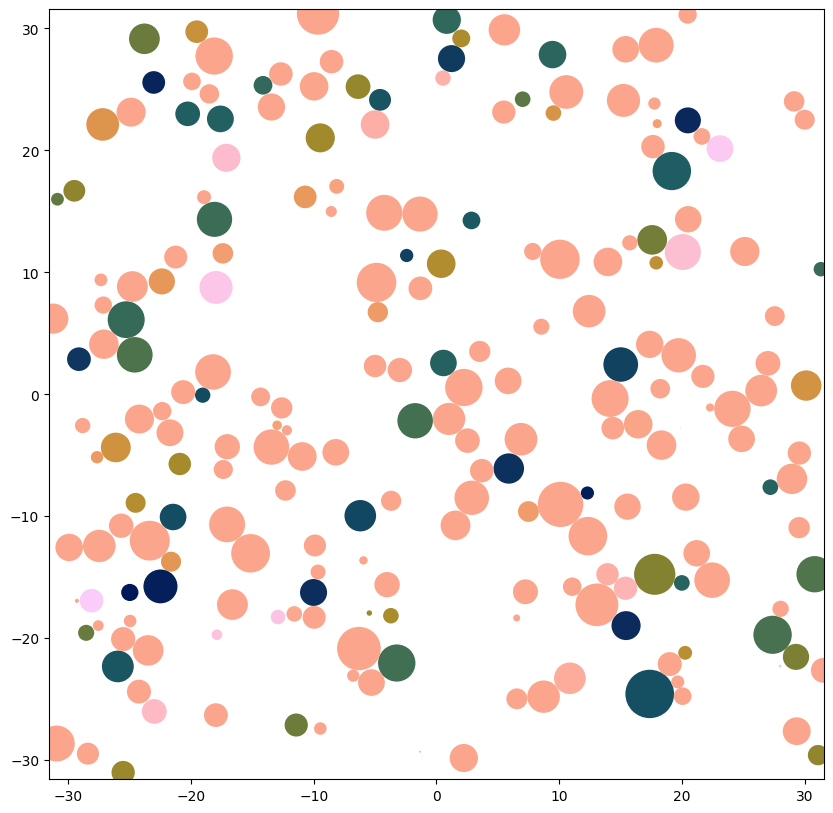

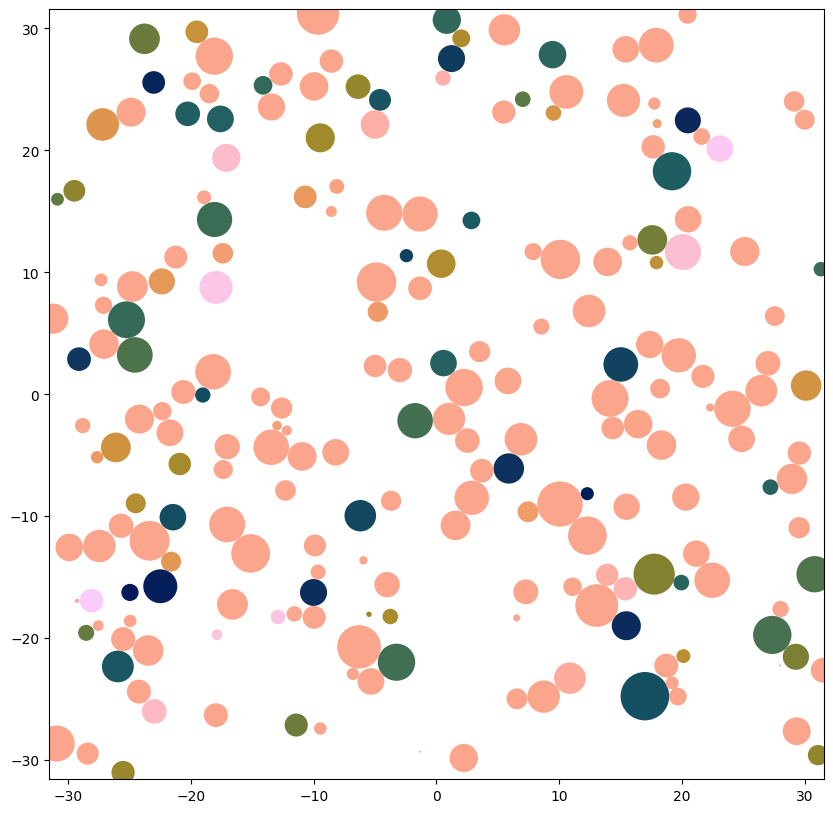

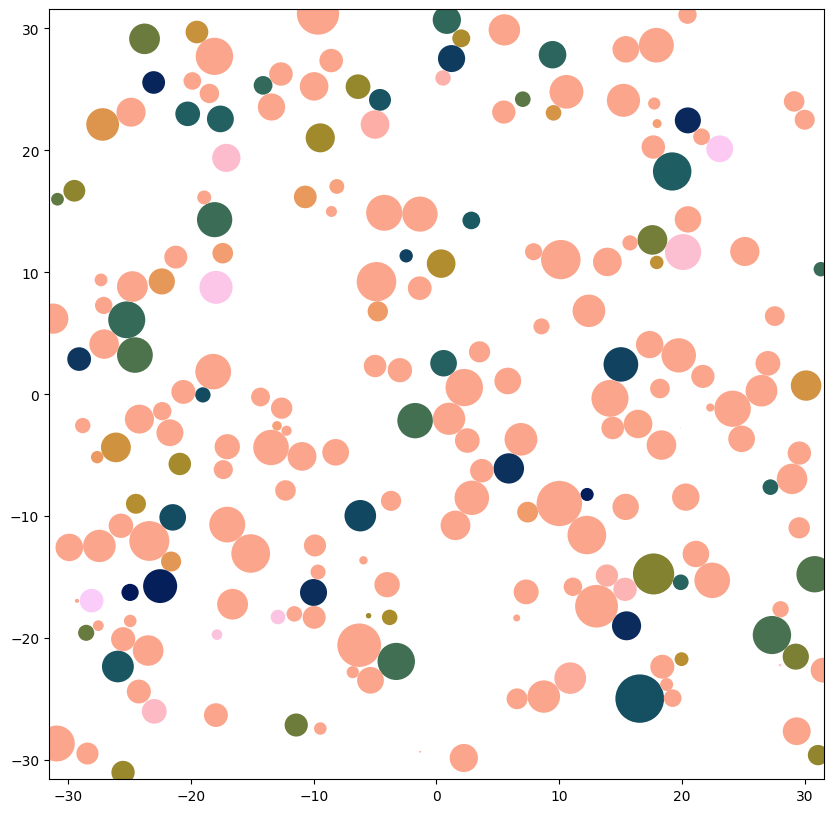

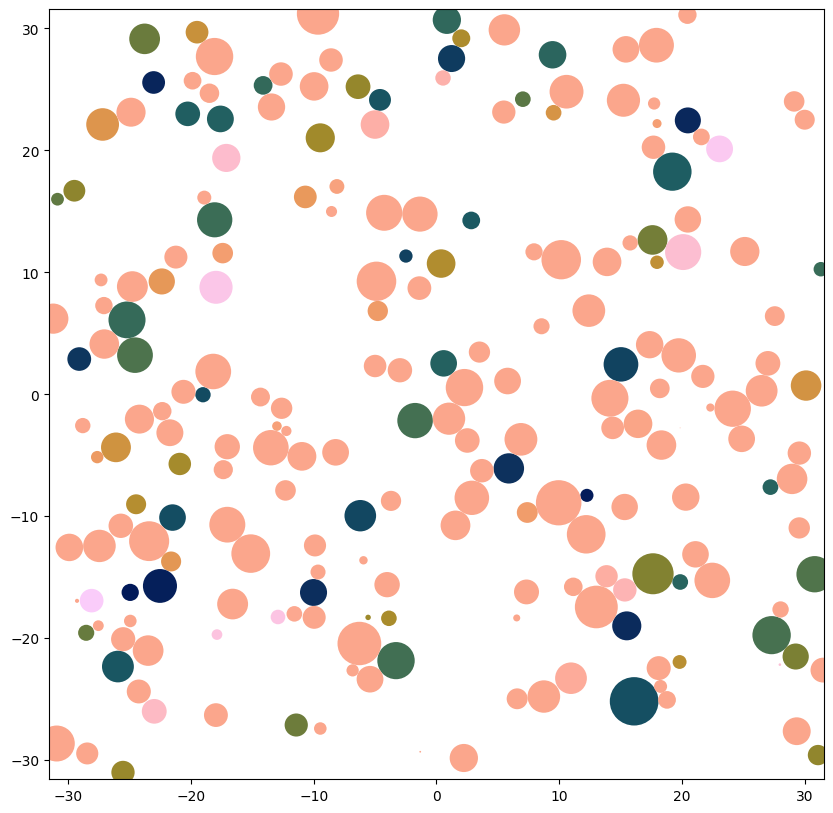

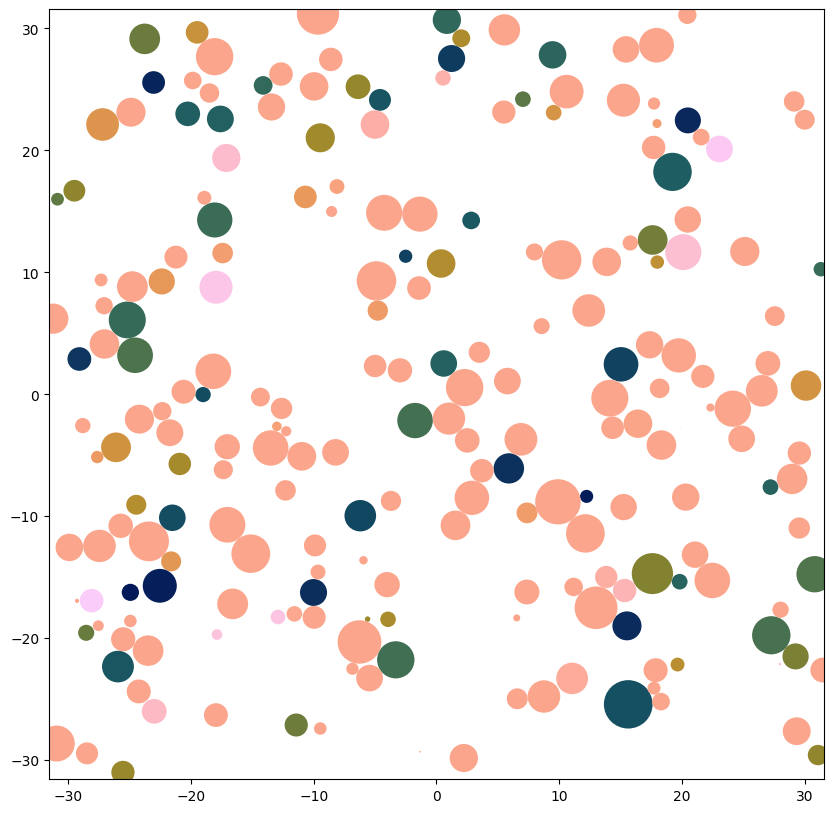

In [71]:
for j in range(500):
    simulate_step_curry(points)
    if j%20 == 0:
        fig, ax = plt.subplots(1,1, figsize=(10,10))
        [ax.add_patch(point.to_patch()) for point in points.values()]

        ax.set_xlim(space_bounds)
        ax.set_ylim(space_bounds)
        plt.show()
        plt.clf()
        plt.close()

### Todo:
- [ ] Implement node as basic Point (not Verlet Integrable)
- [ ] Implement force from Nodes to all points as well potential (ds.inverse_square_with_constant_at_proximity(p1,p2, G=10, r_cutoff=5, constant=1))
- [ ] Place the nodes like feet
- [ ] Setup an animation
        - This will be done by holding on to circle patch handles, then simulating (some) steps, then updating those patch handles with updated data from the simulation.